# 05 — `src/data/feature_engineering.py`: Trend Features + the Temporal Split

This module does two distinct jobs, and it's worth understanding them separately:

1. **`engineer_features()` / `build_processed_dataset()`** — turns raw per-second vitals (spo2, hr, temp, altitude) into the richer feature set the models actually train on (trends, deltas, exposure time).
2. **`temporal_split()`** — divides subjects into train/validation/test sets *without* leaking information across the split, which for time-series data is a genuinely easy thing to get wrong (and, as you'll see below, I did get it wrong on the first attempt — this notebook shows the bug and the fix).

Both are Stage 3 of the data flow diagram, and both are reused identically at training time and (later) live inference time — so training and serving can never quietly drift apart into two different definitions of "trend."

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import synth_data, feature_engineering as fe
from src.config import TREND_WINDOW_MINUTES, ALTITUDE_RISK_ONSET_M

## The five engineered features

From the docstring of `engineer_features()`:

| Feature | What it measures | Why it matters clinically |
|---|---|---|
| `spo2_trend_5min` | Slope of SpO2 over the trailing 5 minutes | HAPE/HACE risk can show up as a **steep negative trend** even before the absolute SpO2 value looks alarming — catching it early matters |
| `hr_trend_5min` | Same idea, for heart rate | A rising HR trend alongside falling SpO2 is a stronger signal than either alone |
| `ascent_rate` | Meters/minute of altitude change | Climbing too fast is itself a risk factor, independent of current vitals |
| `spo2_delta` | `expected_spo2(altitude) - actual_spo2` | The deviation that matters clinically — not raw SpO2 (see the `synth_data` notebook and `docs/lls_mapping.md`) |
| `time_at_altitude_min` | Minutes since altitude first crossed the risk threshold | Symptoms build up the *longer* someone stays high, not just based on current altitude |

Let's build one example trajectory and watch each feature get computed.

In [2]:
rng = np.random.default_rng(3)
raw_traj = synth_data.simulate_trajectory("demo", "HAPE risk", duration_minutes=90, rng=rng)
featured = fe.engineer_features(raw_traj)
featured[["timestamp", "spo2", "spo2_trend_5min", "hr", "hr_trend_5min",
          "altitude", "ascent_rate", "spo2_delta", "time_at_altitude_min"]].iloc[::300].head(10)

,timestamp,spo2,spo2_trend_5min,hr,hr_trend_5min,altitude,ascent_rate,spo2_delta,time_at_altitude_min
0,0.0,97.480872,0.000000,64.233870,0.000000,0.000000,0.000000,0.519128,0.000000
300,300.0,96.207906,-0.012645,61.859526,0.010806,502.615355,20.104614,0.284248,0.000000
600,600.0,94.848641,-0.007356,63.166660,-0.003814,1005.230710,20.104614,0.135667,0.000000
900,900.0,93.762658,-0.001397,57.567831,-0.008281,1507.846065,20.104614,-0.286196,0.000000
1200,1200.0,92.605482,-0.000811,60.808443,0.001744,2010.461421,20.104614,-0.636866,0.000000
1500,1500.0,89.126015,-0.010375,64.852597,0.012781,2513.076776,20.104614,1.334755,0.116667
1800,1800.0,87.581713,-0.007467,62.730462,-0.011491,2714.122918,0.000000,2.275918,5.116667
2100,2100.0,87.764271,0.002399,63.984639,0.004173,2714.122918,0.000000,2.093360,10.116667
2400,2400.0,85.587357,-0.002638,67.328384,0.003763,2714.122918,0.000000,4.270274,15.116667
2700,2700.0,85.278491,-0.002512,73.861529,-0.001953,2714.122918,0.000000,4.579140,20.116667


## The vectorized trend calculation — and why it matters at scale

The slope calculation went through a real performance fix worth understanding, because it illustrates a general pandas lesson.

**First version (works, but slow at scale):**
```python
spo2_roll = df["spo2"].rolling(window=TREND_WINDOW_SAMPLES, min_periods=2)
df["spo2_trend_5min"] = spo2_roll.apply(_slope, raw=False)   # Python callback per window
```

`rolling().apply()` with a Python callback calls a Python function once *per row*, and internally re-scans the whole window each time — `O(n * window_size)` with real per-call Python overhead. Fine for a quick prototype, but with 400 subjects × 5400 rows/subject × a 300-sample window, this became a genuine bottleneck (multiple minutes just to build the feature table).

**Current version (vectorized):**
```python
def _vectorized_slope(series):
    first_full = series.shift(TREND_WINDOW_SAMPLES - 1)
    slope_full = (series - first_full) / (TREND_WINDOW_SAMPLES - 1)
    ...
```

`.shift()` and elementwise subtraction/division run as optimized pandas/numpy C code across the *entire* column at once, instead of a Python function call per row. The math is identical (`(last - first) / span`, the same simple linear slope) — only the mechanism changed. This is a common pattern worth remembering: **whenever you reach for `rolling().apply(python_function)`, ask whether the function can be rewritten as a `shift()`/`diff()` combination instead** — it usually can for anything expressible as "compare this row to one N rows back."

In [3]:
# Direct timing comparison on a moderately large single trajectory
import time

rng = np.random.default_rng(5)
big_traj = synth_data.simulate_trajectory("timing_demo", "Mild AMS", duration_minutes=90, rng=rng)

def _old_style_slope(window):
    if len(window) < 2:
        return 0.0
    span = window.index[-1] - window.index[0]
    return 0.0 if span == 0 else (window.iloc[-1] - window.iloc[0]) / span

t0 = time.perf_counter()
old_result = big_traj["spo2"].rolling(window=300, min_periods=2).apply(_old_style_slope, raw=False)
t_old = time.perf_counter() - t0

t0 = time.perf_counter()
new_result = fe.engineer_features(big_traj)["spo2_trend_5min"]
t_new = time.perf_counter() - t0

print(f"Old rolling().apply() style: {t_old*1000:.1f} ms  (single 90-min trajectory)")
print(f"New vectorized style:        {t_new*1000:.1f} ms")
print(f"Speedup: ~{t_old/t_new:.0f}x")
print("(the new version also does 4 more features in that time, not just this one)")

Old rolling().apply() style: 449.7 ms  (single 90-min trajectory)
New vectorized style:        14.4 ms
Speedup: ~31x
(the new version also does 4 more features in that time, not just this one)


## `ascent_rate` and `time_at_altitude_min`

```python
altitude_diff = df["altitude"].diff(periods=60 * SAMPLE_RATE_HZ)   # 1-minute-back diff
df["ascent_rate"] = (altitude_diff / TREND_WINDOW_MINUTES).fillna(0.0)
```

Straightforward: how much has altitude changed over the last minute, expressed as meters/minute.

`time_at_altitude_min` is a bit more subtle — it needs to find the *first* moment altitude crossed `ALTITUDE_RISK_ONSET_M` (2500m) and then count minutes elapsed since then, continuously, even through small dips (a brief descent into a valley shouldn't reset the "how long have you been exposed" clock — altitude illness risk accumulates with total exposure time, not just current position).

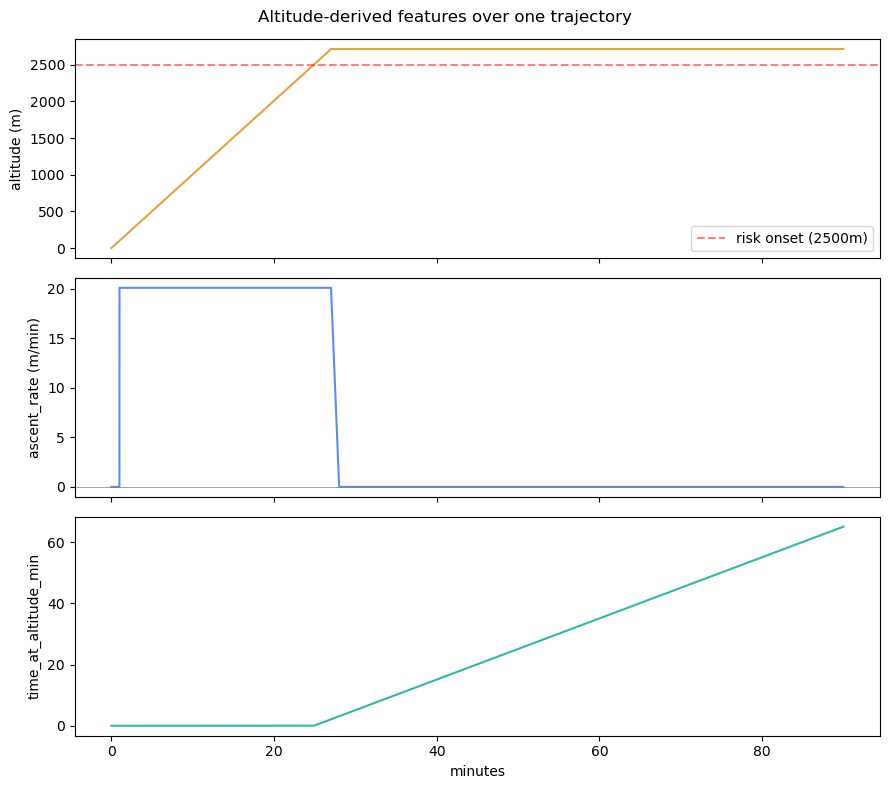

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
minutes = featured["timestamp"] / 60

axes[0].plot(minutes, featured["altitude"], color="#E8A23D")
axes[0].axhline(ALTITUDE_RISK_ONSET_M, color="red", linestyle="--", alpha=0.5, label=f"risk onset ({ALTITUDE_RISK_ONSET_M}m)")
axes[0].set_ylabel("altitude (m)")
axes[0].legend()

axes[1].plot(minutes, featured["ascent_rate"], color="#5B8DEF")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("ascent_rate (m/min)")

axes[2].plot(minutes, featured["time_at_altitude_min"], color="#2FB8A6")
axes[2].set_ylabel("time_at_altitude_min")
axes[2].set_xlabel("minutes")

fig.suptitle("Altitude-derived features over one trajectory")
fig.tight_layout()
plt.show()

Notice `time_at_altitude_min` stays flat at 0 during the ascent (before crossing 2500m), then grows continuously and linearly once the threshold is crossed — even as `ascent_rate` bounces around near zero once cruising altitude is reached.

## `spo2_delta`: the feature that matters most

`spo2_delta = expected_spo2(altitude) - actual_spo2`. When this notebook's XGBoost sibling shows feature importances, `spo2_delta` and `time_at_altitude_min` dominate — which is exactly what `docs/lls_mapping.md` predicts, and a good sanity check that the model is learning something clinically sensible rather than a spurious correlation.

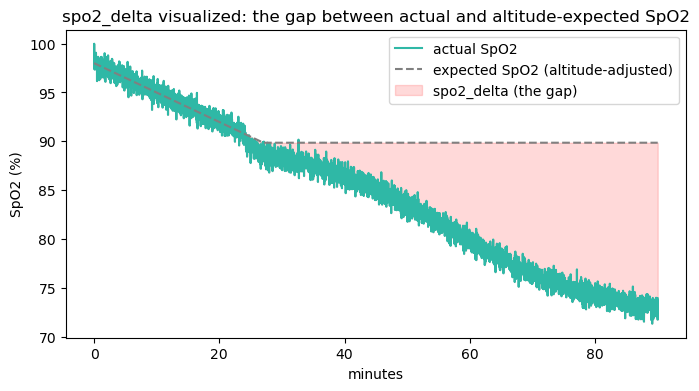

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(minutes, featured["spo2"], label="actual SpO2", color="#2FB8A6")
ax.plot(minutes, featured["expected_spo2"], label="expected SpO2 (altitude-adjusted)", color="gray", linestyle="--")
ax.fill_between(minutes, featured["spo2"], featured["expected_spo2"], alpha=0.15, color="red", label="spo2_delta (the gap)")
ax.set_xlabel("minutes")
ax.set_ylabel("SpO2 (%)")
ax.set_title("spo2_delta visualized: the gap between actual and altitude-expected SpO2")
ax.legend()
plt.show()

## The bug: a plain temporal split can silently starve a class

`temporal_split()`'s docstring is unusually long for a reason — I hit a real bug while building this and want to walk through it, because it's a genuinely common mistake with time-series ML.

**The original (broken) approach:** sort *all* subjects together by `subject_id` (a stand-in for generation time), then cut at 70%/15%/15%. This respects the "never shuffle time-series" rule, but with only ~120 subjects and 5 severity tiers of wildly different rarity (HACE risk is only ~4% of subjects), a single chronological cut across the *whole* population can, purely by chance, put every single HACE-risk subject in the train split. The result: **the test set had zero HACE-risk examples** — not a modeling failure, a sampling failure, but one that would have silently made every metric on that tier meaningless (you can't measure recall on a class with 0 true examples).

**The fix:** group subjects by tier *first*, then apply the same chronological 70/15/15 cut *within each tier's own subject list*. This still respects "no row-shuffling, val/test represent later-in-time-than-train" — it just makes that guarantee hold independently per class, instead of leaving it to chance which tier happens to cluster where in the overall order.

In [6]:
# Reproduce the ORIGINAL buggy behavior on a small population to show the failure mode
small = synth_data.generate_dataset(n_subjects=40, duration_minutes=10, seed=99)
featured_small = fe.build_processed_dataset(small)

# naive (buggy) approach: one chronological cut across ALL subjects, ignoring tier
subject_ids_all = sorted(featured_small["subject_id"].unique())
n = len(subject_ids_all)
naive_test_ids = set(subject_ids_all[int(n*0.85):])  # last 15%
naive_test = featured_small[featured_small["subject_id"].isin(naive_test_ids)]

print("Naive (buggy) chronological split -- tiers present in the resulting 'test' set:")
print(sorted(naive_test["severity_label"].unique()))
print("(compare to all 5 tiers that exist in the full dataset:", sorted(featured_small["severity_label"].unique()), ")")

Naive (buggy) chronological split -- tiers present in the resulting 'test' set:
['HAPE risk', 'Mild AMS', 'Normal', 'Severe AMS']
(compare to all 5 tiers that exist in the full dataset: ['HACE risk', 'HAPE risk', 'Mild AMS', 'Normal', 'Severe AMS'] )


In [7]:
# The FIXED, stratified-temporal split -- run the real function
train_s, val_s, test_s = fe.temporal_split(featured_small)

print("Fixed split -- tiers present in each split:")
for name, split in [("train", train_s), ("val", val_s), ("test", test_s)]:
    print(f"  {name}: {sorted(split['severity_label'].unique())}")

Fixed split -- tiers present in each split:
  train: ['HACE risk', 'HAPE risk', 'Mild AMS', 'Normal', 'Severe AMS']
  val: ['HAPE risk', 'Mild AMS', 'Normal', 'Severe AMS']
  test: ['HAPE risk', 'Mild AMS', 'Normal']


With a small 40-subject demo population some tiers may still be too rare to get a val/test example (the function's fallback: fewer than 3 subjects in a tier group puts all of them in train, explicitly, rather than leaving an empty split silently) — but the real pipeline runs on 400 subjects specifically so every tier has enough subjects to split meaningfully across all three sets, which you can verify in `01_data_exploration.ipynb`.

## Why split by whole subject, never by row

One more detail worth calling out: even the *fixed* split still operates on whole `subject_id`s, never individual rows. If we split by row instead, a test-set row at minute 47 of some subject's trajectory could sit right next to a train-set row at minute 46 of the *same* subject — the model would implicitly be tested on data adjacent to what it trained on, from a person whose individual resting HR and altitude sensitivity it has already partially learned. That's leakage, and it would make test performance look better than it will actually generalize. Splitting on whole subjects closes this off completely — a test subject is a person (well, simulated person) the model has never seen even one second of.

## Summary

`feature_engineering.py` turns raw vitals into five clinically-motivated derived features (vectorized for real performance at scale), then splits subjects into train/val/test in a way that's both leakage-free (whole-subject boundaries) and statistically sound for rare classes (per-tier stratification) — while still honoring the core time-series rule of never shuffling rows. `tests/test_pipeline.py::test_temporal_split_no_subject_overlap` now guards against the specific bug described above regressing.

**Next notebook:** `06_rule_baseline.ipynb` — the first model: simple if/else thresholds, and why it has to exist before any ML model is trusted.